In [1]:
import pandas as pd
import importlib
import numpy as np

import plotly.express as px
import matplotlib.pyplot as plt

import irina.utility_functions as uf

In [2]:
importlib.reload(uf)

<module 'Irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/Irina/utility_functions.py'>

In [6]:
df_global = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").drop_duplicates()

In [7]:
def get_stats_year(year, path="df_country_subfield/"):
    df_year = pd.read_csv(uf.PATH+path+f"{year}.csv", index_col="country")
    return (
        uf.get_country_stats(df_year)
        .assign(log_total_articles=lambda df: np.log(df.total_articles))
        .merge(uf.df_country[["alpha-2", "alpha-3", "region"]], left_index=True, right_on="alpha-2", how="left")
    )

In [8]:
year = 2023
df_global.query("year == @year").set_index("subfield_id").probability_individual.to_frame("GL").T

subfield_id,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
GL,0.003311,0.002319,0.002019,0.001772,0.003803,0.006851,0.000953,0.000069,0.002479,0.016605,...,0.000335,0.00172,0.001475,0.000198,0.000008,0.001533,0.000703,0.00198,0.001149,0.001681


In [10]:
year = 1990
df_country_subfield = pd.concat([
        pd.read_csv(uf.PATH+f"df_country_subfield/individual_{year}.csv", index_col=0),
        df_global.query("year == @year").assign(subfield=lambda df: df.subfield_id.astype(str)).set_index("subfield").counts_individual.to_frame("Global").T
    ], axis=0)

df_country_subfield_collab = pd.concat([
        pd.read_csv(uf.PATH+f"df_country_subfield/collaborative_{year}.csv", index_col=0),
        df_global.query("year == @year").assign(subfield=lambda df: df.subfield_id.astype(str)).set_index("subfield").counts_all.to_frame("Global").T
    ], axis=0)

# Counts: countries by production dynamics (all subfields) -- share in the global production

In [11]:
years = [1980, 2000, 2023]
year = 2000

In [40]:
n = 10
df_top_indiv_list = []
df_top_collab_list = []

for year_loop in years:
    df_country_subfield_indiv = pd.concat([
            pd.read_csv(uf.PATH+f"df_country_subfield/individual_{year_loop}.csv", index_col=0),
            df_global.query("year == @year_loop").assign(subfield=lambda df: df.subfield_id.astype(str)).set_index("subfield").counts_individual.to_frame("GL").T
        ], axis=0)

    df_country_subfield_collab = pd.concat([
            pd.read_csv(uf.PATH+f"df_country_subfield/collaborative_{year_loop}.csv", index_col=0),
            df_global.query("year == @year_loop").assign(subfield=lambda df: df.subfield_id.astype(str)).set_index("subfield").counts_all.to_frame("GL").T
        ], axis=0)

    df_top_indiv_list.append((
        df_country_subfield_indiv
        .sum(axis=1)
        .to_frame("total_production")
        .assign(global_share=lambda df: df.total_production / df.total_production.iloc[-1])
        .sort_values("global_share", ascending=False)
    ).head(n+1).reset_index(names="country")[["country", "global_share"]].assign(year=year_loop).iloc[1:].reset_index(names="position"))

    df_top_collab_list.append((
        df_country_subfield_collab
        .sum(axis=1)
        .to_frame("total_production")
        .assign(global_share=lambda df: df.total_production / df.total_production.iloc[-1])
        .sort_values("global_share", ascending=False)
    ).head(n+1).reset_index(names="country")[["country", "global_share"]].assign(year=year_loop).iloc[1:].reset_index(names="position"))

df_top_indiv = pd.concat(df_top_indiv_list)
df_top_collab = pd.concat(df_top_collab_list)
df_top_compare = (
    df_top_indiv
    .merge(df_top_collab, how="left", on=["position", "year"], suffixes=("_individual", "_collaborative"))
)

In [24]:
px.bar(
    (
        df_top_compare
        .query("year == @year")
        # .sort_values("position", ascending=False)
        # .assign(position_str=lambda df: df.position.astype(str))
    ),
    x="position",
    y="global_share_individual",
    # color="year",
    # barmode="group",
    text="country_individual",
    title=f"Top-10 countries by article production: {year}",
    width=500
)

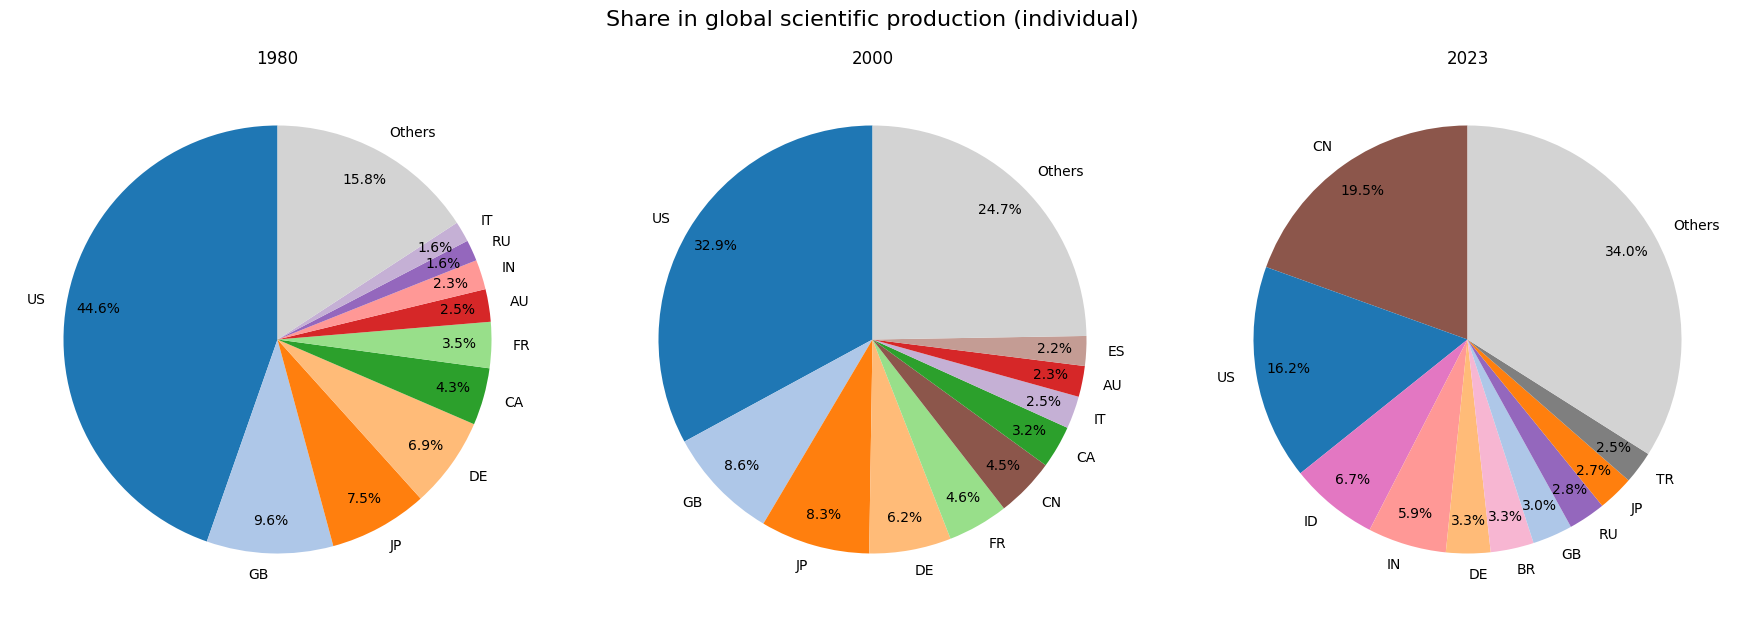

In [26]:

top_n = 10
all_countries = df_top_compare["country_individual"].unique()

# Assign a consistent color to each country
cmap = plt.cm.tab20.colors
country_colors = {country: cmap[i % len(cmap)] for i, country in enumerate(all_countries)}
others_color = "lightgray"

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

fig.suptitle("Share in global scientific production (individual)", fontsize=16, y=1.02)

for ax, year_loop in zip(axes, years):
    df_year = df_top_compare.query("year == @year_loop").sort_values("global_share_individual", ascending=False)

    # Take top_n countries
    df_top = df_year.head(top_n)

    values = list(df_top.global_share_individual)
    labels = list(df_top.country_individual)

    # Add "Others" slice
    sum_top = sum(values)
    values.append(1 - sum_top)
    labels.append("Others")

    # Assign colors for this pie
    colors = [country_colors.get(c, others_color) for c in labels]
    colors[-1] = others_color  # make "Others" gray

    # Draw pie chart
    ax.pie(
        values,
        labels=labels,
        autopct="%.1f%%",
        startangle=90,
        pctdistance=0.85,  # move percentages closer to the edge
        colors=colors
    )
    ax.set_title(str(year_loop))

plt.tight_layout()
# plt.show()
# plt.savefig("../images/countries_global_share_individual.png")

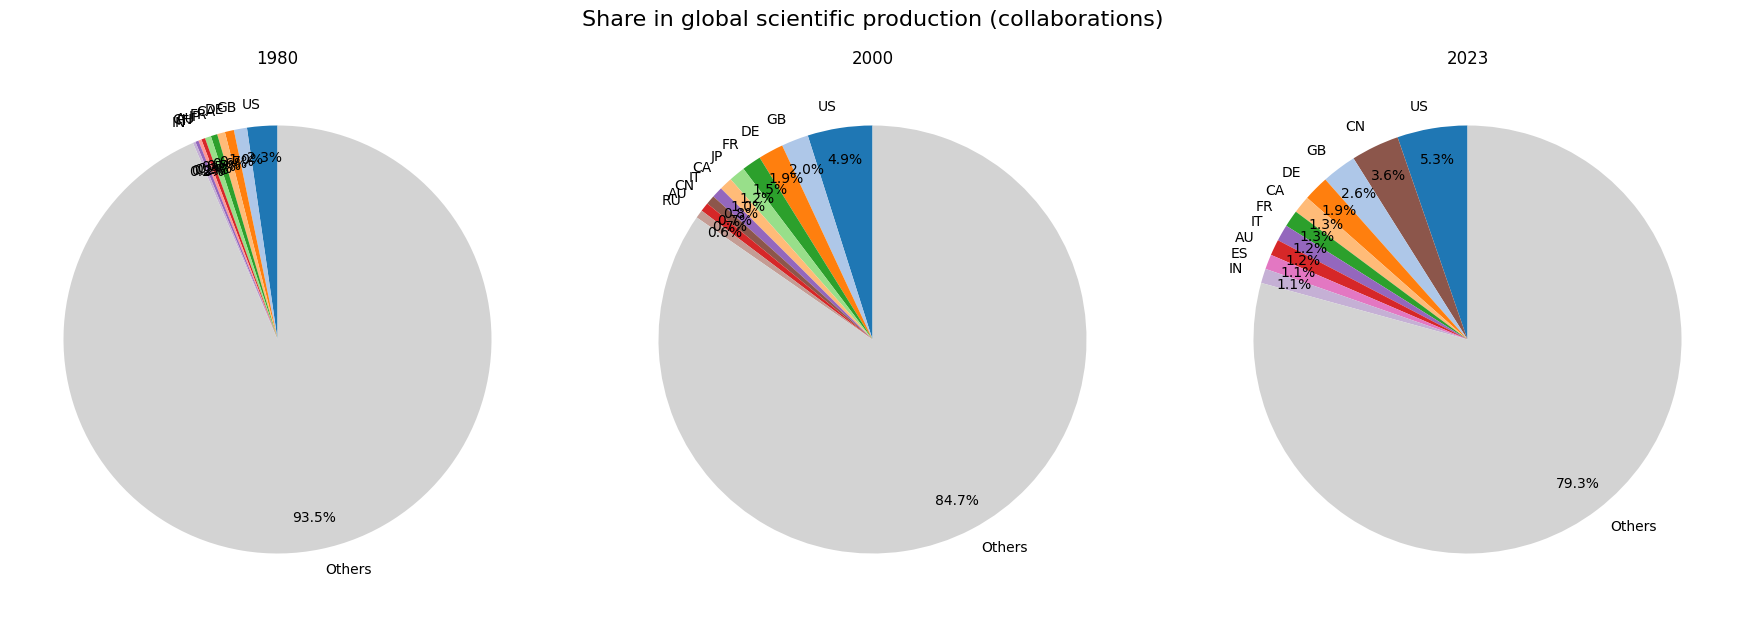

In [27]:
years = [1980, 2000, 2023]
top_n = 10
all_countries = df_top_compare["country_collaborative"].unique()

# Assign a consistent color to each country
cmap = plt.cm.tab20.colors
country_colors = {country: cmap[i % len(cmap)] for i, country in enumerate(all_countries)}
others_color = "lightgray"

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

fig.suptitle("Share in global scientific production (collaborations)", fontsize=16, y=1.02)

for ax, year in zip(axes, years):
    df_year = df_top_compare.query("year == @year").sort_values("global_share_collaborative", ascending=False)

    # Take top_n countries
    df_top = df_year.head(top_n)

    values = list(df_top.global_share_collaborative)
    labels = list(df_top.country_collaborative)

    # Add "Others" slice
    sum_top = sum(values)
    values.append(1 - sum_top)
    labels.append("Others")

    # Assign colors for this pie
    colors = [country_colors.get(c, others_color) for c in labels]
    colors[-1] = others_color  # make "Others" gray

    # Draw pie chart
    ax.pie(
        values,
        labels=labels,
        autopct="%.1f%%",
        startangle=90,
        pctdistance=0.85,  # move percentages closer to the edge
        colors=colors
    )
    ax.set_title(str(year))

plt.tight_layout()
# plt.show()
# plt.savefig("../images/countries_global_share_collab.png")

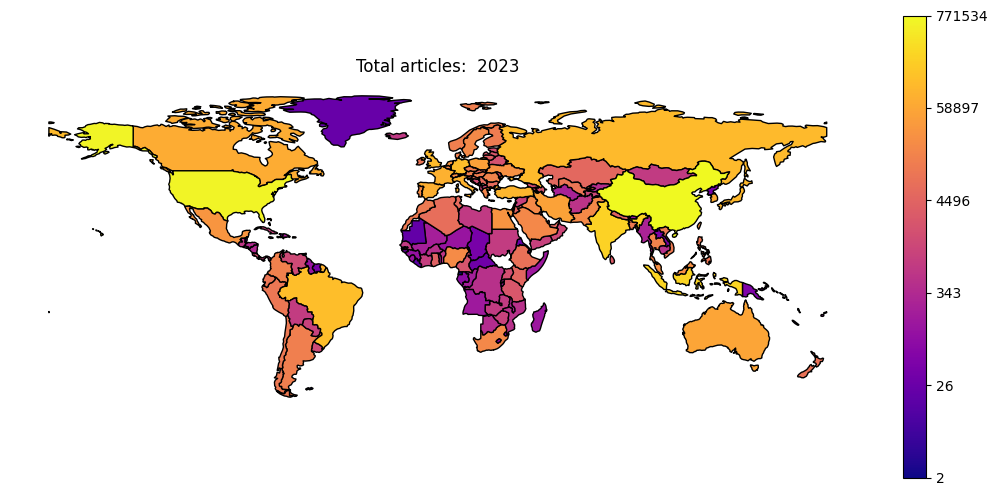

In [31]:
# year = 1980
df_stats_indiv = get_stats_year(year, path="df_country_subfield/individual_")

fig, ax = uf.plot_map_continuous(df_stats_indiv, "log_total_articles", title="Total articles: ", year=year, log=True)

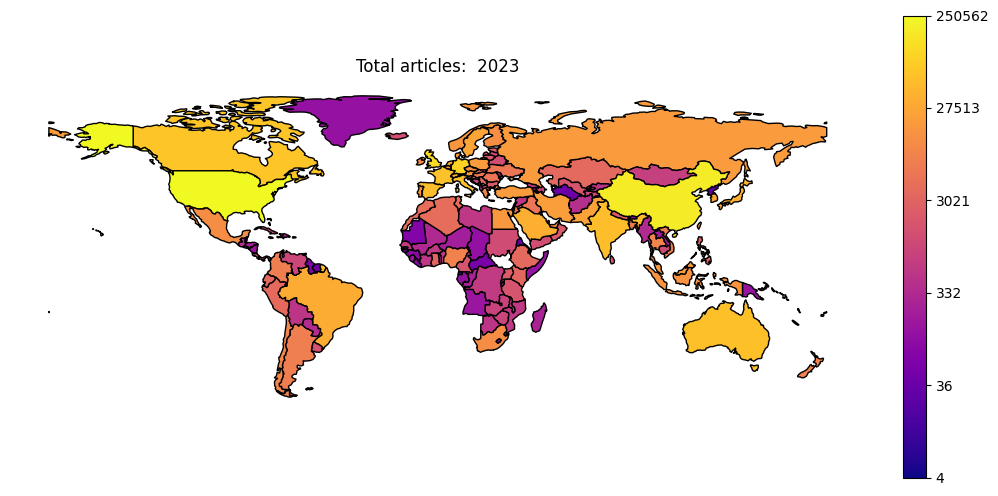

In [32]:
# year = 1980
df_stats_collab = get_stats_year(year, path="df_country_subfield/collaborative_")

fig, ax = uf.plot_map_continuous(df_stats_collab, "log_total_articles", title="Total articles: ", year=year, log=True)

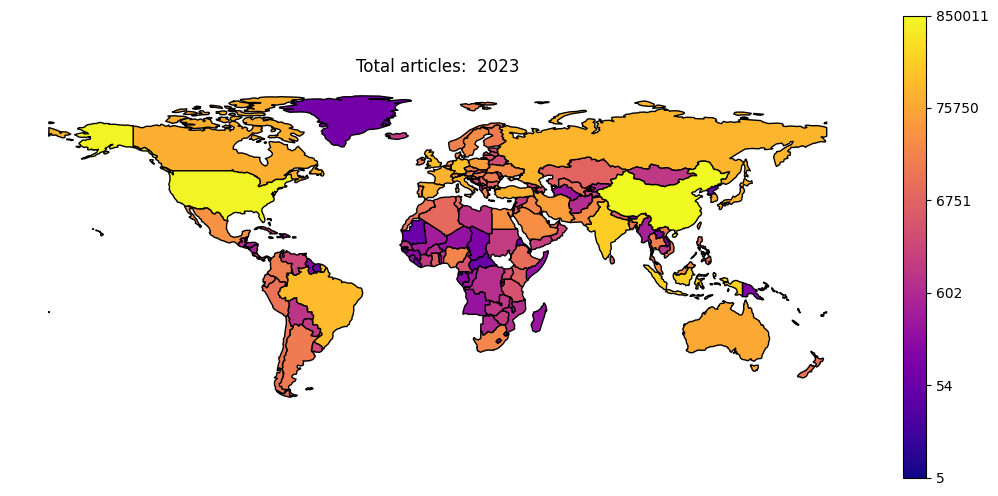

In [38]:
# year = 1980
df_stats_indiv = get_stats_year(year, path="df_country_subfield/w_countries_")

fig, ax = uf.plot_map_continuous(df_stats_indiv, "log_total_articles", title="Total articles: ", year=year, log=True)

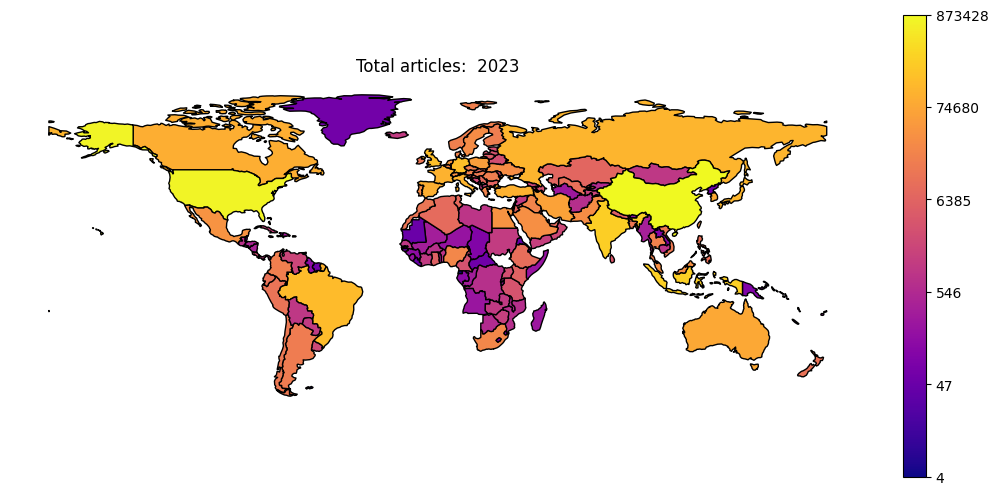

In [39]:
# year = 1980
df_stats_indiv = get_stats_year(year, path="df_country_subfield/w_authors_")

fig, ax = uf.plot_map_continuous(df_stats_indiv, "log_total_articles", title="Total articles: ", year=year, log=True)

Text(0.5, 1.0, 'Lorenz curve (total individual production)')

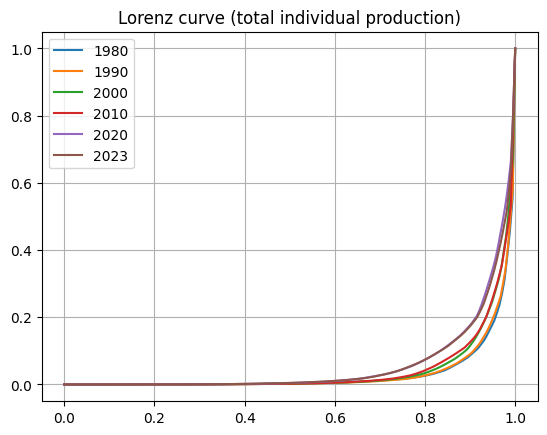

In [33]:
years = [1980, 1990, 2000, 2010, 2020, 2023]

for year in years:
    df_plot = (
        get_stats_year(year, path="df_country_subfield/individual_")
        .sort_values("total_articles")
        .reset_index()
        .total_articles
        .cumsum()
        .to_frame("lorenz")
    )
    plt.plot(np.linspace(0, 1, len(df_plot.index)), df_plot["lorenz"] / df_plot.lorenz.max(), label=str(year))
plt.legend()
plt.grid()
plt.title("Lorenz curve (total individual production)")

Text(0.5, 1.0, 'Lorenz curve (total collaborative production)')

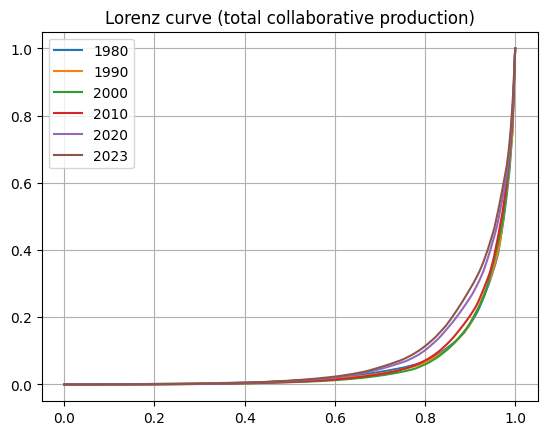

In [34]:
years = [1980, 1990, 2000, 2010, 2020, 2023]

for year in years:
    df_plot = (
        get_stats_year(year, path="df_country_subfield/collaborative_")
        .sort_values("total_articles")
        .reset_index()
        .total_articles
        .cumsum()
        .to_frame("lorenz")
    )
    plt.plot(np.linspace(0, 1, len(df_plot.index)), df_plot["lorenz"] / df_plot.lorenz.max(), label=str(year))
plt.legend()
plt.grid()
plt.title("Lorenz curve (total collaborative production)")

Text(0.5, 1.0, 'Lorenz curve (total collaborative production)')

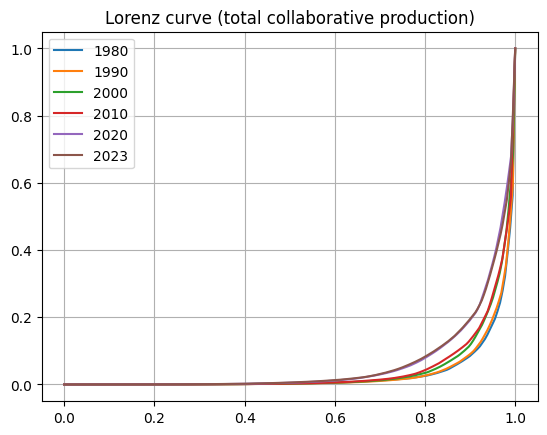

In [36]:
years = [1980, 1990, 2000, 2010, 2020, 2023]

for year in years:
    df_plot = (
        get_stats_year(year, path="df_country_subfield/w_countries_")
        .sort_values("total_articles")
        .reset_index()
        .total_articles
        .cumsum()
        .to_frame("lorenz")
    )
    plt.plot(np.linspace(0, 1, len(df_plot.index)), df_plot["lorenz"] / df_plot.lorenz.max(), label=str(year))
plt.legend()
plt.grid()
plt.title("Lorenz curve (total collaborative production)")

Text(0.5, 1.0, 'Lorenz curve (total collaborative production)')

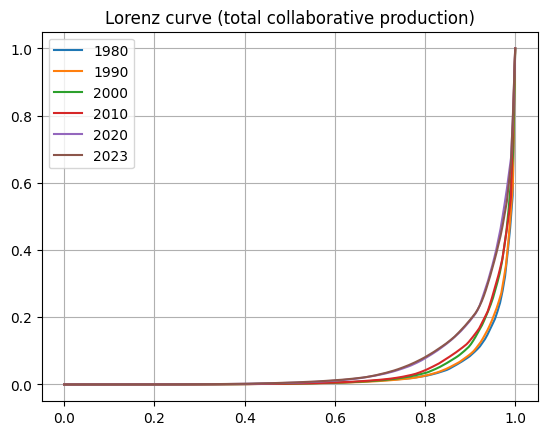

In [37]:
years = [1980, 1990, 2000, 2010, 2020, 2023]

for year in years:
    df_plot = (
        get_stats_year(year, path="df_country_subfield/w_authors_")
        .sort_values("total_articles")
        .reset_index()
        .total_articles
        .cumsum()
        .to_frame("lorenz")
    )
    plt.plot(np.linspace(0, 1, len(df_plot.index)), df_plot["lorenz"] / df_plot.lorenz.max(), label=str(year))
plt.legend()
plt.grid()
plt.title("Lorenz curve (total collaborative production)")

In [65]:
uf.get_country_info("KR")

,name,region,sub-region,code
119,"Korea, Republic of",Asia,Eastern Asia,KR


# Global contribution by subfield

In [164]:
year = 2023

In [42]:
df_country_subfield = pd.concat([
        pd.read_csv(uf.PATH+f"df_country_subfield/individual_{year}.csv", index_col=0),
        df_global.query("year == @year").assign(subfield=lambda df: df.subfield_id.astype(str)).set_index("subfield").counts_individual.to_frame("Global").T
    ], axis=0)

df_country_subfield_collab = pd.concat([
        pd.read_csv(uf.PATH+f"df_country_subfield/collaborative_{year}.csv", index_col=0),
        df_global.query("year == @year").assign(subfield=lambda df: df.subfield_id.astype(str)).set_index("subfield").counts_all.to_frame("Global").T
    ], axis=0)

df_country_subfield_contrib = (
    df_country_subfield
    .div(df_country_subfield.loc["Global"], axis=1)
    .drop("Global")
)
df_country_subfield_contrib

df_country_subfield_contrib_collab = (
    df_country_subfield_collab
    .div(df_country_subfield_collab.loc["Global"], axis=1)
    .drop("Global")
)

df_max_by_subfield = (
    pd.DataFrame({
        "max_value": df_country_subfield_contrib.max(),
        "country": df_country_subfield_contrib.idxmax(),
    })
    .merge(
        uf.df_topics[["subfield_id", "subfield_name", "field_name", "domain_name"]].drop_duplicates().assign(subfield=lambda df: df.subfield_id.astype(str)),
        left_index=True, right_on="subfield", how="left")
)

df_max_by_subfield_collab = (
    pd.DataFrame({
        "max_value": df_country_subfield_contrib_collab.max(),
        "country": df_country_subfield_contrib_collab.idxmax(),
    })
    .merge(
        uf.df_topics[["subfield_id", "subfield_name", "field_name", "domain_name"]].drop_duplicates().assign(subfield=lambda df: df.subfield_id.astype(str)),
        left_index=True, right_on="subfield", how="left")
)


In [71]:
domain_name = ("Physical Sciences")
px.bar(
    df_max_by_subfield.query("domain_name == @domain_name"),
    x="max_value",
    y="subfield_name",
    color="country",
    height=1100
)

In [44]:
country_list = df_country_subfield_contrib.sum(axis=1).sort_values(ascending=False).head(30).index.to_list()
uf.plotly_heatmap(
    df_country_subfield_contrib.loc[country_list],
    x_labels=df_country_subfield.columns,
    y_labels=country_list,
    x_type="subfield",
    y_type="country",
    colorscale="non-symmetric",
    z_min=0, z_max=1,
    title=f"Country's contribution to global production: {year}"
)

# Probabilities (scientific fingerprint)

In [72]:
year = 2023

df_country_subfield = (
    pd.read_csv(uf.PATH+f"df_country_subfield/individual_{year}.csv", index_col="country")
    .assign(total=lambda df: df.sum(axis=1))
    .sort_values("total", ascending=False)
    .drop("total", axis=1)
)

In [73]:
df_country_subfield_prob = (
    df_country_subfield
    .div(df_country_subfield.sum(axis=1), axis=0)
)

In [74]:
top_n = 20
subset_countries = df_country_subfield_prob.index
subset_countries = df_country_subfield_prob.index[:top_n]

fig = uf.plotly_heatmap(
    df_country_subfield_prob.loc[subset_countries],
    x_labels=df_country_subfield_prob.columns,
    y_labels=subset_countries,
    x_type="subfield",
    y_type="country",
    colorscale="non-symmetric",
    z_min=0, z_max=0.02,
    line_height=30,
    title=f"Scientific fingerprint: top-{top_n} countries by production in {year}"
)
fig.show()
# fig.write_image(f"../images/fingerprint_top{top_n}_{year}.png",
#                 width=1200, height=600, scale=2)

In [217]:
# df_country_stats = (
#     df_country_subfield_prob
#     .assign(
#         entropy=lambda df: -df.mul(np.log(df)).sum(axis=1),
#         norm_entropy=lambda df: df.entropy / np.log(len(df.columns) - 1),
#         total_articles=df_country_subfield.sum(axis=1),
#         log_total_articles=lambda df: np.log(df.total_articles),
#         gini=df_country_subfield.apply(uf.gini, axis=1)
#     )
#     .merge(uf.df_country[["alpha-2", "alpha-3", "region"]], left_index=True, right_on="alpha-2", how="left")
#     .rename(columns={"alpha-2": "country"})
#     .set_index("country")
#     .sort_values('total_articles', ascending=False)
#     [["region", "entropy", "norm_entropy", "total_articles", "log_total_articles", "gini", "alpha-3"]]
# )

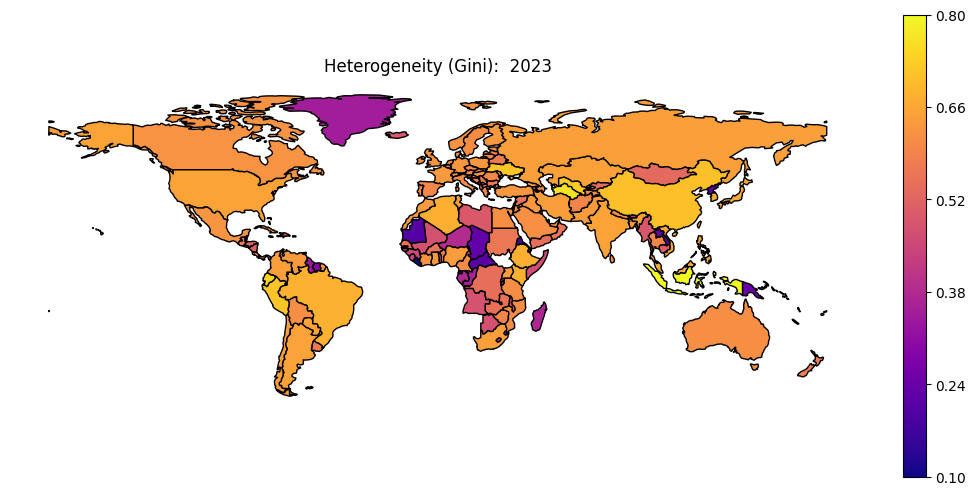

In [67]:
# year = 2023
importlib.reload(uf)
df_stats = get_stats_year(year, path="df_country_subfield/individual_")

fig, ax = uf.plot_map_continuous(df_stats, "gini", title="Heterogeneity (Gini): ", year=year, log=False, range=(0.1, 0.8))

In [68]:
px.scatter(
    df_stats.reset_index(),
    x="log_total_articles",
    y="gini",
    title=f"Gini vs number of articles: {year} (smaller Gini -- less articles)",
    color="region",
    hover_name="alpha-2",
    hover_data=["region", "total_articles", "gini"],
)